<a href="https://colab.research.google.com/github/MaeSantos/CCDEPLRL/blob/main/Prodi_Santos_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1 - Mount Google Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2 - Set Dataset Path


In [3]:
dataset_path = "/content/drive/MyDrive/Dog_Emotions"

# Step 3 - Import Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

#Step 4 - Prepare Image Dataset

In [5]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Step 5 - Load Training Dataset

In [6]:
train_data = datagen.flow_from_directory(dataset_path, target_size=(128,128), batch_size=32, class_mode='categorical', subset='training')

Found 24 images belonging to 3 classes.


#Step 6 - Load Validation

In [7]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
validation_data = datagen.flow_from_directory(dataset_path, target_size=(128,128), batch_size=32, class_mode='categorical', subset='validation')

Found 6 images belonging to 3 classes.


#Step 7 - Build Simple CNN

In [8]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3),
activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Step 8 - Compile Model

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Step 9 - Train Model

In [10]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 1.1113 - val_accuracy: 0.3333 - val_loss: 3.6300
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step - accuracy: 0.3750 - loss: 2.5129 - val_accuracy: 0.3333 - val_loss: 4.5075
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step - accuracy: 0.5000 - loss: 2.8813 - val_accuracy: 0.3333 - val_loss: 7.2332
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step - accuracy: 0.3333 - loss: 5.2618 - val_accuracy: 0.5000 - val_loss: 3.5799
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6250 - loss: 2.1212 - val_accuracy: 0.3333 - val_loss: 5.5743
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step - accuracy: 0.3333 - loss: 2.2845 - val_accuracy: 0.3333 - val_loss: 3.6437
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7083 - loss: 0.6675 - val_accuracy: 0.3333 - val_loss: 1.6634
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9167 - loss: 0.1889 - val_accuracy: 0.1667 - val_loss: 2.

#Step 10 - Evaluate Model

In [11]:
loss, accuraccy = model.evaluate(validation_data)

print("Validation Accuracy:", accuraccy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3333 - loss: 2.4343
Validation Accuracy: 0.3333333432674408


#Step 11 - Plot Accuracy

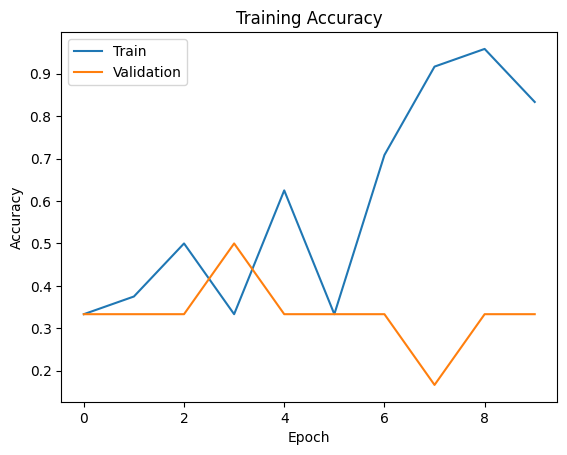

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

Step 12 - Save Model

In [13]:
model.save("cnn_classifier.h5")
from google.colab import files
files.download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 13 - Deploy with Streamlit

To deploy this model with Streamlit, you would typically create a file named `app.py` on your local machine or a deployment platform. This file will contain the Streamlit application code. Below is an example of what that `app.py` file would look like.

In [14]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import PIL.Image

def load_model():
    model = tf.keras.models.load_model('cnn_classifier.h5')
    return model

model = load_model()

class_labels = ['Angry', 'Happy', 'Sad']

st.title('Dog Emotion Classifier')
st.write('Upload an image of a dog to predict its emotion!')

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = PIL.Image.open(uploaded_file).convert('RGB')
    st.image(img, caption='Uploaded Image', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    img = img.resize((128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions)
    predicted_emotion = class_labels[predicted_class_index]
    confidence = np.max(predictions) * 100

    st.success(f"Predicted Emotion: **{predicted_emotion}** with **{confidence:.2f}%** confidence")

st.markdown("---")
st.markdown("**Note:** For this app to run locally, ensure you have `streamlit`, `tensorflow`, and `Pillow` installed (`pip install streamlit tensorflow Pillow`). Also, make sure the `cnn_classifier.h5` model file is in the same directory as `app.py`.")

Overwriting app.py


### How to run this Streamlit app:

1.  **Download the model:** Ensure you have downloaded the `cnn_classifier.h5` file from your Colab session.
2.  **Save the `app.py` content:** Copy the content of the `%%writefile app.py` cell above and save it as `app.py` in the **same directory** where you saved `cnn_classifier.h5`.
3.  **Install dependencies:** Open your terminal or command prompt and run:
    ```bash
    pip install streamlit tensorflow Pillow
    ```
4.  **Run the app:** In the same directory where `app.py` is saved, run:
    ```bash
    streamlit run app.py
    ```
    This will open the Streamlit application in your web browser.

Saving 4cee3bc7-6682-49d9-844e-c98c51416dcb.jpg to 4cee3bc7-6682-49d9-844e-c98c51416dcb.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Class: Happy


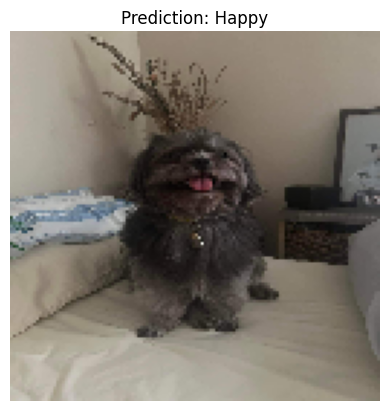

In [15]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = image.load_img(filename, target_size=(128,128))

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_labels = list(train_data.class_indices.keys())

plt.imshow(img)
plt.axis('off')

print("Predicted Class:", class_labels[predicted_class])

plt.title("Prediction: " + class_labels[predicted_class])
plt.show()